2026-03-13 08:33:08,648 - INFO - working directory: /home/cation-pi/Documents/kelompokD_sk5004/pca


,x,y
0,1.1,2.0
1,1.3,2.2
2,1.2,1.9
3,1.4,2.3
4,1.5,2.4


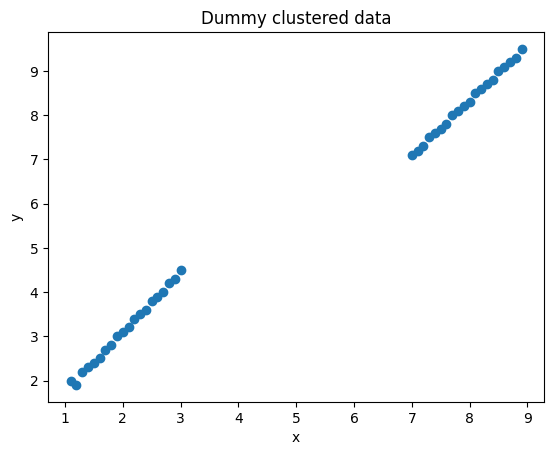

In [6]:
import sys
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# konfigurasi logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)])

# setup direktori
current_dir = Path.cwd()
logging.info(f"working directory: {current_dir}")

# dataset
df = pd.read_csv("experiment2.csv")
display(df.head())

X = df.values

plt.scatter(df["x"], df["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dummy clustered data")
plt.show()

In [2]:
mean_vec = np.mean(X, axis=0)
std_vec = np.std(X, axis=0)

X_std = (X - mean_vec) / std_vec

logging.info(f"rata-rata X_std: {np.mean(X_std):.20f}")
logging.info(f"standar deviasi X_std: {np.std(X_std):.20f}")

df_std_preview = pd.DataFrame(X_std)
display(df_std_preview.head())

2026-03-13 08:32:00,204 - INFO - rata-rata X_std: -0.00000000000000012212
2026-03-13 08:32:00,205 - INFO - standar deviasi X_std: 0.99999999999999988898


,0,1
0,-1.297480,-1.396721
1,-1.230942,-1.321628
2,-1.264211,-1.434267
3,-1.197673,-1.284082
4,-1.164405,-1.246536


In [3]:
# step 2
cov_mat = np.cov(X_std.T)
logging.info(f"dimensi covariance matrix: {cov_mat.shape}")

# step 3: Σv = λv
# Σ = cov_mat, v = eigenvector, λ = eigenvalue.
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
logging.info(f"jumlah eigenvalues: {len(eigen_vals)}")
logging.info(f"dimensi matriks eigenvectors: {eigen_vecs.shape}")
print('\nEigenvalues:')
print(eigen_vals)

2026-03-13 08:32:10,728 - INFO - dimensi covariance matrix: (2, 2)
2026-03-13 08:32:10,729 - INFO - jumlah eigenvalues: 2
2026-03-13 08:32:10,729 - INFO - dimensi matriks eigenvectors: (2, 2)

Eigenvalues:
[2.04671282 0.00456923]


In [4]:
# step 4
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

# step 5 dan 6
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

w = np.hstack((eigen_pairs[0][1][:, np.newaxis], eigen_pairs[1][1][:, np.newaxis]))
logging.info(f"dimensi matriks proyeksi w: {w.shape}")
print('matriks w:\n', w)

2026-03-13 08:32:21,516 - INFO - dimensi matriks proyeksi w: (2, 2)
matriks w:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


2026-03-13 08:32:31,846 - INFO - dimensi dataset sebelum pca: (40, 2)
2026-03-13 08:32:31,847 - INFO - dimensi dataset setelah pca: (40, 2)


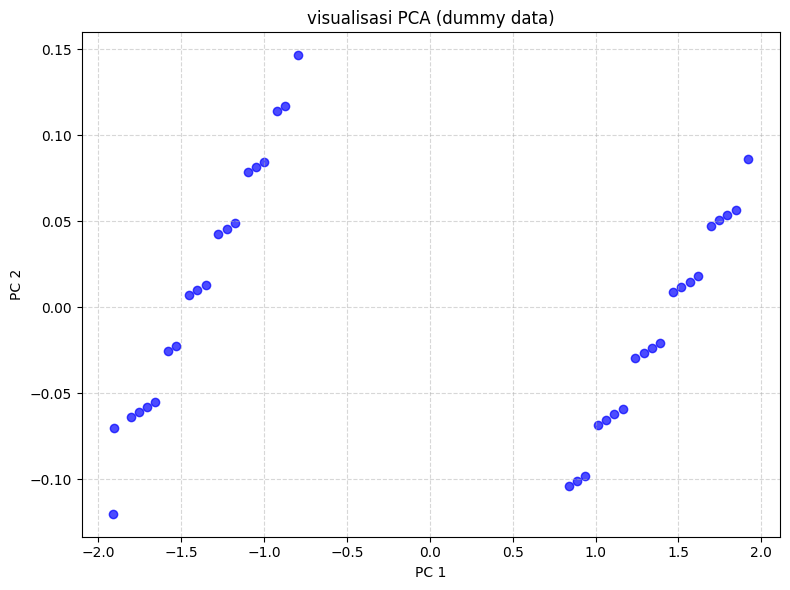

In [5]:
X_pca = X_std.dot(w)

logging.info(f"dimensi dataset sebelum pca: {X_std.shape}")
logging.info(f"dimensi dataset setelah pca: {X_pca.shape}")

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', alpha=0.7)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('visualisasi PCA (dummy data)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

masih terpisah tapi sudah dalam 1 garis, artinya dia tidak menghilangkan karakteristik datanya.

In [7]:
# mengembalikan hasil pca ke data asli semula

# inverse
X_std_reconstructed = X_pca.dot(w.T)

# kembali ke skala asli
X_reconstructed = X_std_reconstructed * std_vec + mean_vec

print("Data asli:")
print(X[:5])

print("\nData setelah PCA → inverse:")
print(X_reconstructed[:5])

Data asli:
[[1.1 2. ]
 [1.3 2.2]
 [1.2 1.9]
 [1.4 2.3]
 [1.5 2.4]]

Data setelah PCA → inverse:
[[1.1 2. ]
 [1.3 2.2]
 [1.2 1.9]
 [1.4 2.3]
 [1.5 2.4]]


In [10]:
# hasil inversenya itu tidak semua titik data kembali, ada yg hilang. hitung berapa persen yg hilang tersebut.

# selisih data
diff = X - X_reconstructed
error = np.linalg.norm(diff)

# norm data asli
norm = np.linalg.norm(X)
# persen kehilangan
percent_lost = (error / norm) * 100

print(f"Persentase informasi hilang: {percent_lost:.2f}%")

Persentase informasi hilang: 0.00%


In [9]:
# eigenvalues
eigen_vals = eigen_vals

# total variance
total_var = np.sum(eigen_vals)

# variance yang dijelaskan PC1
explained_pc1 = eigen_vals[0] / total_var

# persen informasi hilang
lost_info = (1 - explained_pc1) * 100

print(f"Variance dijelaskan PC1: {explained_pc1*100:.2f}%")
print(f"Informasi hilang: {lost_info:.2f}%")

Variance dijelaskan PC1: 99.78%
Informasi hilang: 0.22%


pca digunakan di preprocessing ml.
kasus lain :datanya banyak noise (titik yg tidak bermakna), caranya: 2 kolom dijadikan 1, lalu dikemblaikan menjadi 2 lagi. saat dikembalikan, data2 noise itu akan hilang, pca hanya membaca data2 penting saja. 

tugas: mereduce gambar, mengurangi noise (sertakan before dan after, serta pca nya, dan dibalikin lagi seperti apa).

laporannya dalam pdf. 

harus data real. konversi gambar, visualisasi data, filter noise. jangan cuma tabel. 